# 📒 MobileNet v2 — Pneumonie (3 classes)

0.9%

1.8%

2.8%

3.7%

4.6%

...

Epoch 08/25 • train 0.270 • val 0.367 • acc 0.841


Epoch 09/25 • train 0.230 • val 0.462 • acc 0.761


Epoch 10/25 • train 0.215 • val 0.402 • acc 0.825


Epoch 11/25 • train 0.202 • val 0.439 • acc 0.854


Epoch 12/25 • train 0.149 • val 0.392 • acc 0.842
⏹️ Early-stop.


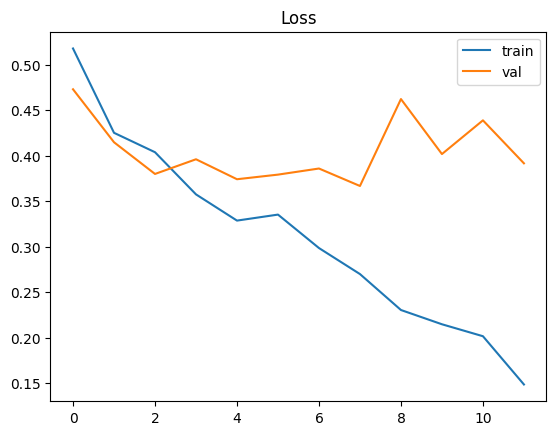

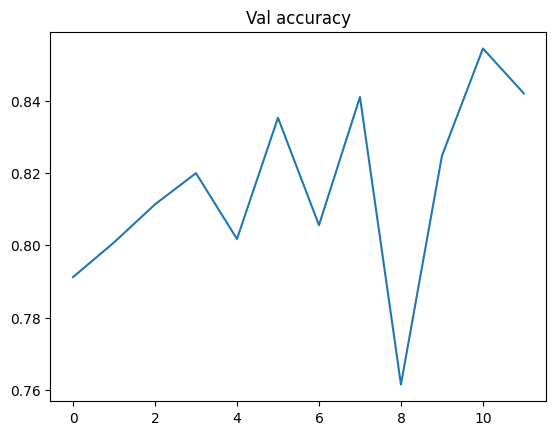

                       precision    recall  f1-score   support

               Normal       0.96      1.00      0.98       243
Pneumonie_Bactérienne       0.88      0.82      0.85       531
     Pneumonie_Virale       0.68      0.74      0.71       270

             accuracy                           0.84      1044
            macro avg       0.84      0.85      0.85      1044
         weighted avg       0.85      0.84      0.84      1044



In [1]:
import os, random, datetime, json, math
from pathlib import Path
from collections import Counter

import torch, torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED); torch.manual_seed(SEED)

BASE = Path.home()/"Zoidberg"
DATA_DIR   = BASE/"data/raw/chest_Xray/train"
MODEL_DIR  = BASE/"mobile"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

transform = T.Compose([
    T.Resize((224,224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(8),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def load_dataset():
    ds = torchvision.datasets.ImageFolder(DATA_DIR, transform)
    new = []
    for p,_ in ds.samples:
        l = 0 if "normal"   in p.lower() else (
            1 if "bacter" in p.lower() else 2)
        new.append((p,l))
    ds.samples = new; ds.targets = [l for _,l in new]
    ds.classes = ["Normal","Pneumonie_Bactérienne","Pneumonie_Virale"]
    return ds

ds = load_dataset()
train_len = int(0.8*len(ds))
val_len   = len(ds) - train_len
train_ds, val_ds = torch.utils.data.random_split(ds,[train_len,val_len])

batch = 16
train_dl = torch.utils.data.DataLoader(train_ds,batch,shuffle=True)
val_dl   = torch.utils.data.DataLoader(val_ds,batch)

cnt = Counter(ds.targets)
weights = torch.tensor([sum(cnt.values())/cnt[i] for i in range(3)])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torchvision.models.mobilenet_v2(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.last_channel,3)
model.to(device)

loss_fn = nn.CrossEntropyLoss(weight=weights.to(device))
opt     = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt,'min',patience=2,factor=0.3)

EPOCHS = 25
best_val = math.inf; patience=0
train_loss_hist, val_loss_hist, val_acc_hist = [],[],[]

for epoch in range(1,EPOCHS+1):
    model.train(); tl=0
    for x,y in train_dl:
        x,y = x.to(device), y.to(device)
        opt.zero_grad(); out = model(x); loss = loss_fn(out,y)
        loss.backward(); opt.step(); tl += loss.item()
    tl /= len(train_dl); train_loss_hist.append(tl)

    model.eval(); vl=0; y_true=[]; y_pred=[]
    with torch.no_grad():
        for x,y in val_dl:
            x,y = x.to(device), y.to(device)
            out = model(x); vl += loss_fn(out,y).item()
            y_true.extend(y.cpu().tolist())
            y_pred.extend(out.argmax(1).cpu().tolist())
    vl /= len(val_dl); val_loss_hist.append(vl)
    acc = (torch.tensor(y_true)==torch.tensor(y_pred)).float().mean().item()
    val_acc_hist.append(acc)
    scheduler.step(vl)

    print(f"Epoch {epoch:02d}/{EPOCHS} • train {tl:.3f} • val {vl:.3f} • acc {acc:.3f}")

    if vl < best_val - 1e-3:
        best_val = vl; patience=0
        torch.save(model.state_dict(), MODEL_DIR/f"best_{datetime.datetime.now():%Y%m%d_%H%M%S}.pt")
    else:
        patience += 1
        if patience == 4:
            print("⏹️ Early-stop."); break

plt.plot(train_loss_hist,label='train'); plt.plot(val_loss_hist,label='val');
plt.legend(); plt.title('Loss'); plt.show()
plt.plot(val_acc_hist); plt.title('Val accuracy'); plt.show()

print(classification_report(y_true,y_pred,target_names=ds.classes))